# Benchmark EDA plots

This notebook replaces the four earlier graph notebooks. Shared loading, cleaning, and plotting helpers are defined once, then reused for each benchmark dataset.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("..") / "data" / "graphs"
NUMERIC_COLS = ["QED", "SA", "MW", "LogP"]
BINARY_COLS = ["Lipinski", "BRENK", "PAINS", "Glaxo"]
STATUS_PALETTE = {
    "bad": "#F4A7A7",
    "good": "#A8E6A3",
    "ambiguous": "#A7C7E7",
}


## Shared helpers

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns={"logP": "LogP"}).copy()


def clean_numeric_columns(df: pd.DataFrame, numeric_cols=NUMERIC_COLS) -> pd.DataFrame:
    df = df.copy()
    for col in numeric_cols:
        if col not in df.columns:
            continue
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def clean_binary_columns(df: pd.DataFrame, binary_cols=BINARY_COLS) -> pd.DataFrame:
    df = df.copy()
    truthy = {"true", "1", "yes", "y", "t"}
    falsy = {"false", "0", "no", "n", "f"}
    for col in binary_cols:
        if col not in df.columns:
            continue
        values = df[col].astype(str).str.strip().str.lower()
        df[col] = values.map(lambda value: True if value in truthy else False if value in falsy else pd.NA)
    return df


def load_benchmark_csv(file_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / file_name)
    df = normalize_columns(df)
    df = clean_numeric_columns(df)
    df = clean_binary_columns(df)
    return df


def available_columns(df: pd.DataFrame, columns) -> list[str]:
    return [col for col in columns if col in df.columns]


In [3]:
def ordered_categories(df: pd.DataFrame, category_col: str, order=None) -> list:
    if order:
        existing = set(df[category_col].dropna())
        return [category for category in order if category in existing]
    return list(df[category_col].dropna().unique())


def palette_for_categories(categories, palette=None):
    if isinstance(palette, dict):
        return {category: palette.get(category) for category in categories}
    colors = sns.color_palette("Set2", n_colors=max(len(categories), 1)).as_hex()
    return dict(zip(categories, colors))


def plot_numeric_boxplots(
    df: pd.DataFrame,
    category_col: str,
    numeric_cols=NUMERIC_COLS,
    order=None,
    palette=None,
    title: str | None = None,
):
    cols = available_columns(df, numeric_cols)
    categories = ordered_categories(df, category_col, order)
    color_map = palette_for_categories(categories, palette)
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes = axes.flatten()

    for index, col in enumerate(cols):
        ax = axes[index]
        sns.boxplot(
            data=df,
            x=category_col,
            y=col,
            hue=category_col,
            order=categories,
            palette=color_map,
            legend=False,
            width=0.55,
            ax=ax,
        )
        medians = df.groupby(category_col, dropna=False)[col].median()
        y_min, y_max = ax.get_ylim()
        offset = (y_max - y_min) * 0.025
        for position, category in enumerate(categories):
            median = medians.get(category)
            if pd.isna(median):
                continue
            ax.text(
                position,
                median + offset,
                f"median: {median:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                color="#2F2F2F",
            )
        ax.set_title(f"{col} distribution")
        ax.set_xlabel("")
        ax.set_xticklabels([])

    for index in range(len(cols), len(axes)):
        axes[index].set_visible(False)

    handles = [Patch(facecolor=color_map[category], label=category) for category in categories]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 4), frameon=False)
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=(0, 0.08, 1, 0.95))
    plt.show()
    plt.close(fig)


def plot_numeric_kdes(
    df: pd.DataFrame,
    numeric_cols=NUMERIC_COLS,
    category_col: str | None = None,
    categories=None,
    palette=None,
    title: str | None = None,
):
    plot_df = df.copy()
    if category_col and categories:
        plot_df = plot_df[plot_df[category_col].isin(categories)]

    cols = available_columns(plot_df, numeric_cols)
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes = axes.flatten()

    for index, col in enumerate(cols):
        sns.kdeplot(
            data=plot_df,
            x=col,
            hue=category_col,
            hue_order=categories,
            palette=palette,
            fill=True,
            common_norm=False,
            ax=axes[index],
        )
        axes[index].set_title(f"{col} density")

    for index in range(len(cols), len(axes)):
        axes[index].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
    plt.close(fig)


def plot_binary_feature_share(
    df: pd.DataFrame,
    category_col: str,
    binary_cols=BINARY_COLS,
    order=None,
    palette=None,
    title: str | None = None,
):
    cols = available_columns(df, binary_cols)
    categories = ordered_categories(df, category_col, order)
    summary = df.groupby(category_col, dropna=False)[cols].mean().reset_index()
    long_summary = summary.melt(id_vars=category_col, var_name="Feature", value_name="Share")

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=long_summary,
        x="Feature",
        y="Share",
        hue=category_col,
        hue_order=categories,
        palette=palette,
        ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
    ax.set_ylim(0, min(1.15, max(1, long_summary["Share"].max() + 0.15)))
    ax.set_ylabel("Share of molecules")
    if title:
        ax.set_title(title)
    ax.legend(title=category_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_category_pie(
    df: pd.DataFrame,
    category_col: str,
    order=None,
    palette=None,
    title: str | None = None,
):
    categories = ordered_categories(df, category_col, order)
    counts = df[category_col].value_counts().reindex(categories).dropna()
    color_map = palette_for_categories(list(counts.index), palette)
    colors = [color_map[category] for category in counts.index]

    fig, ax = plt.subplots(figsize=(6, 5))
    wedges, _, autotexts = ax.pie(
        counts,
        labels=None,
        autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
        startangle=90,
        colors=colors,
        pctdistance=0.72,
        textprops={"fontsize": 9},
    )
    for text in autotexts:
        text.set_fontweight("bold")
    ax.axis("equal")
    if title:
        ax.set_title(title)
    legend_labels = [f"{category} ({int(count)})" for category, count in counts.items()]
    ax.legend(wedges, legend_labels, title=category_col, bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Dataset configuration

In [4]:
DATASETS = {
    "absolute_score": {
        "file": "absolute_score.csv",
        "category_col": "Status",
        "palette": STATUS_PALETTE,
        "comparisons": [
            {
                "name": "Status reason",
                "category_col": "Status_Reason",
                "order": [
                    "bad extreme",
                    "bad medchem",
                    "nature toxin",
                    "good",
                    "side effects",
                    "addiction",
                    "antitumor",
                ],
                "palette": {
                    "bad extreme": "#F4A7A7",
                    "bad medchem": "#F4A7A7",
                    "nature toxin": "#F4A7A7",
                    "good": "#A8E6A3",
                    "side effects": "#A7C7E7",
                    "addiction": "#A7C7E7",
                    "antitumor": "#A7C7E7",
                },
            }
        ],
    },
    "pair_smiles": {
        "file": "pair_smiles.csv",
        "category_col": None,
    },
    "pair_stability": {
        "file": "pair_stability.csv",
        "category_col": "More stable molecule",
        "comparisons": [
            {
                "name": "Stability",
                "category_col": "More stable molecule",
                "order": ["less stable bro", "more stable bro"],
                "palette": {"less stable bro": "#F4A7A7", "more stable bro": "#A8E6A3"},
            }
        ],
    },
    "pair_structure": {
        "file": "pair_structure.csv",
        "category_col": "Status",
        "comparisons": [
            {
                "name": "Quality groups",
                "category_col": "Status",
                "order": ["very bad bro", "bad bro", "good bro"],
                "palette": {"very bad bro": "#F4A7A7", "bad bro": "#FFD37A", "good bro": "#A8E6A3"},
            },
            {
                "name": "Activity",
                "category_col": "Status",
                "order": ["more active bro", "less active bro"],
                "palette": {"more active bro": "#A8E6A3", "less active bro": "#FFD37A"},
            },
            {
                "name": "Metabolism",
                "category_col": "Status",
                "order": ["pro-drug", "active metabolite"],
                "palette": {"pro-drug": "#A7C7E7", "active metabolite": "#D7B5F5"},
            },
        ],
    },
}

loaded_data = {name: load_benchmark_csv(config["file"]) for name, config in DATASETS.items()}
{name: df.shape for name, df in loaded_data.items()}


{'absolute_score': (299, 19),
 'pair_smiles': (48, 16),
 'pair_stability': (97, 20),
 'pair_structure': (99, 18)}

## Overview plots

## absolute_score

absolute_score: 299 rows, 19 columns


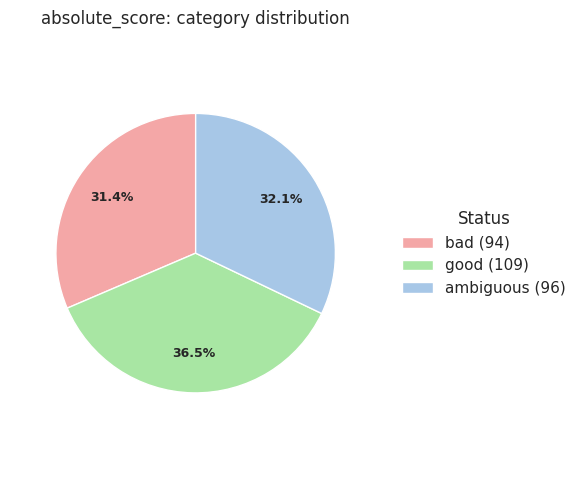

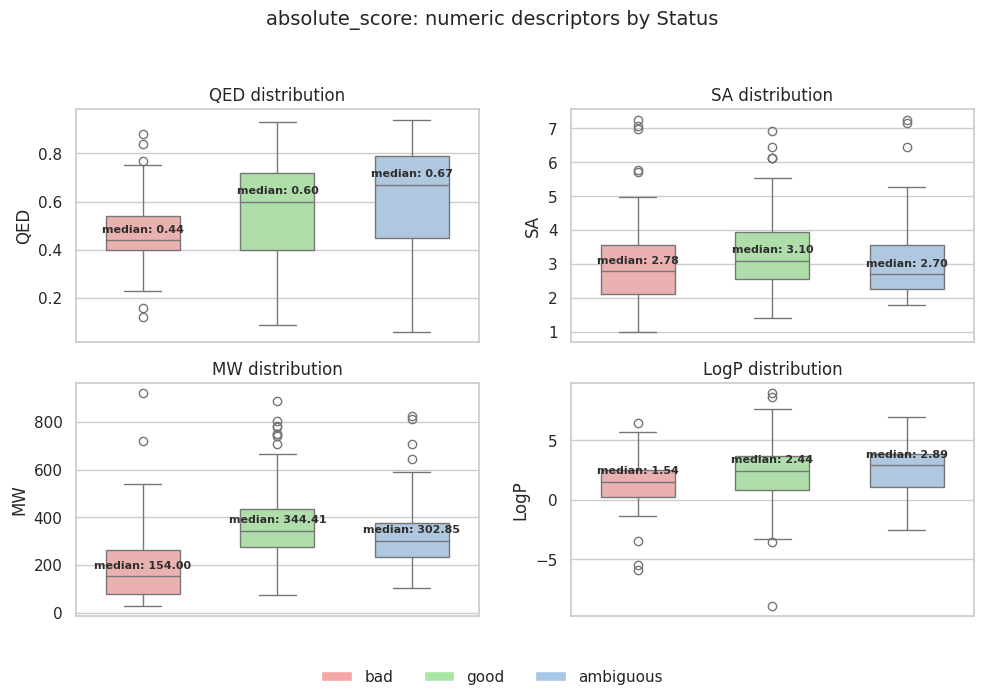

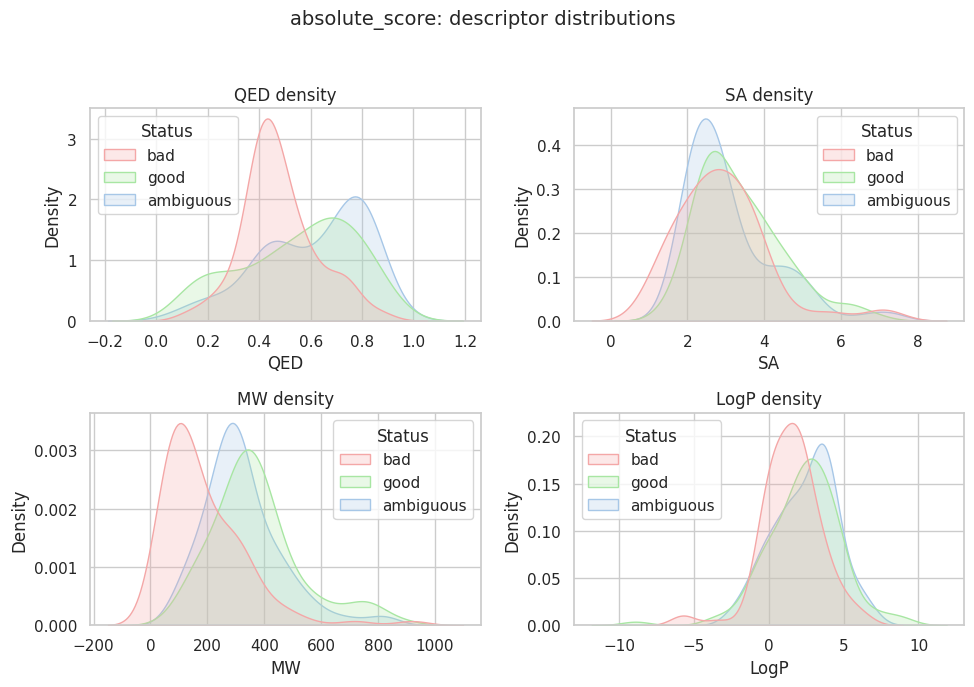

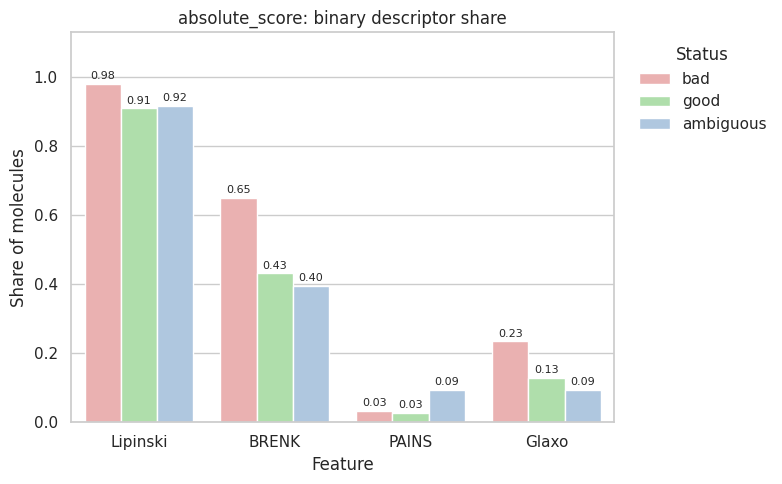

## pair_smiles

pair_smiles: 48 rows, 16 columns


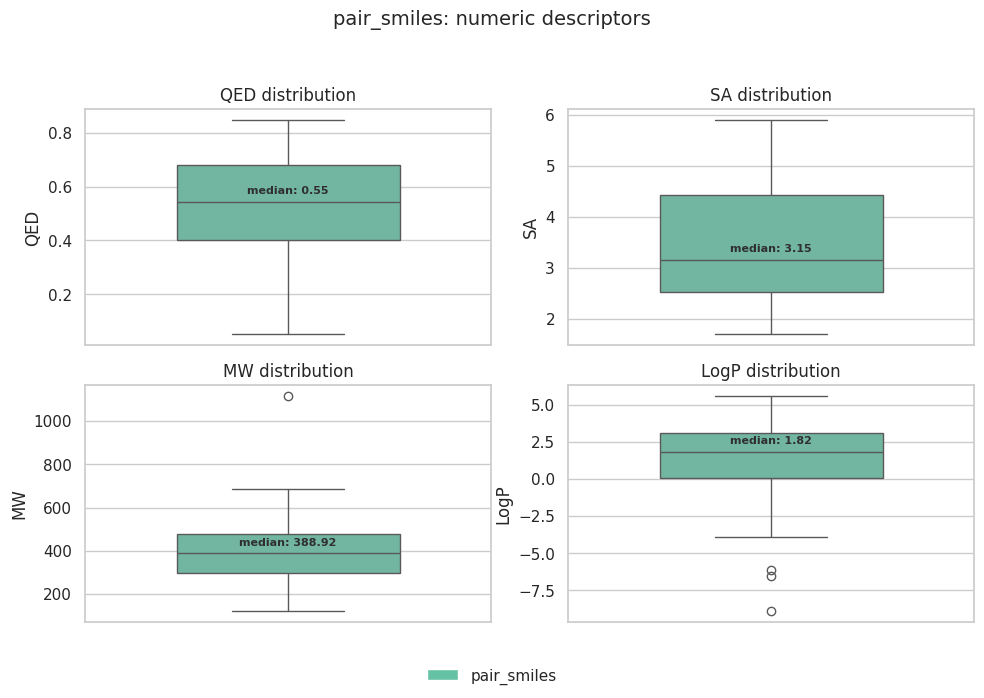

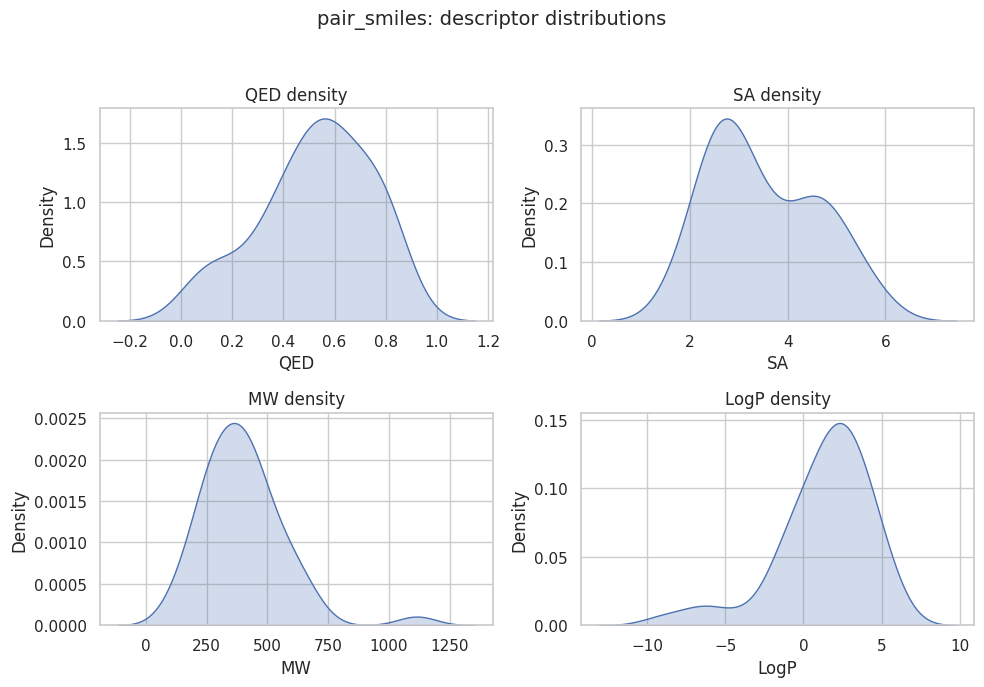

## pair_stability

pair_stability: 97 rows, 20 columns


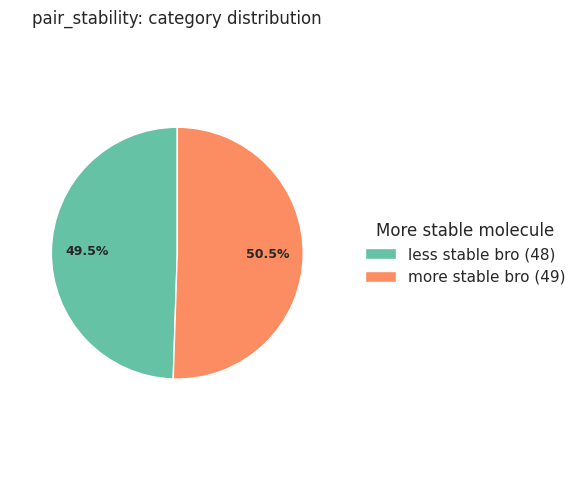

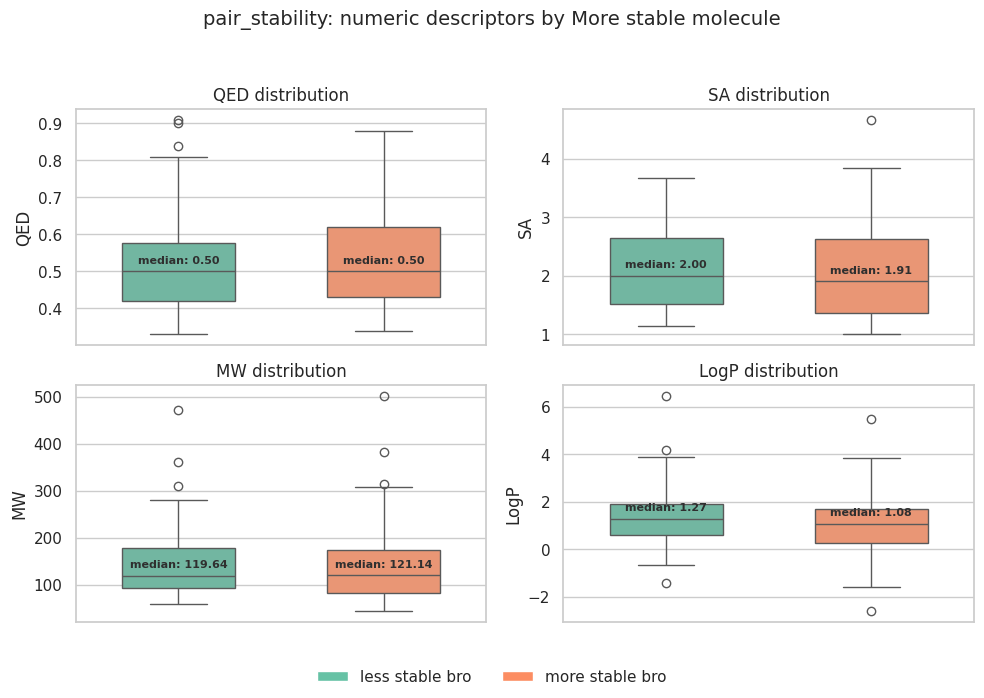

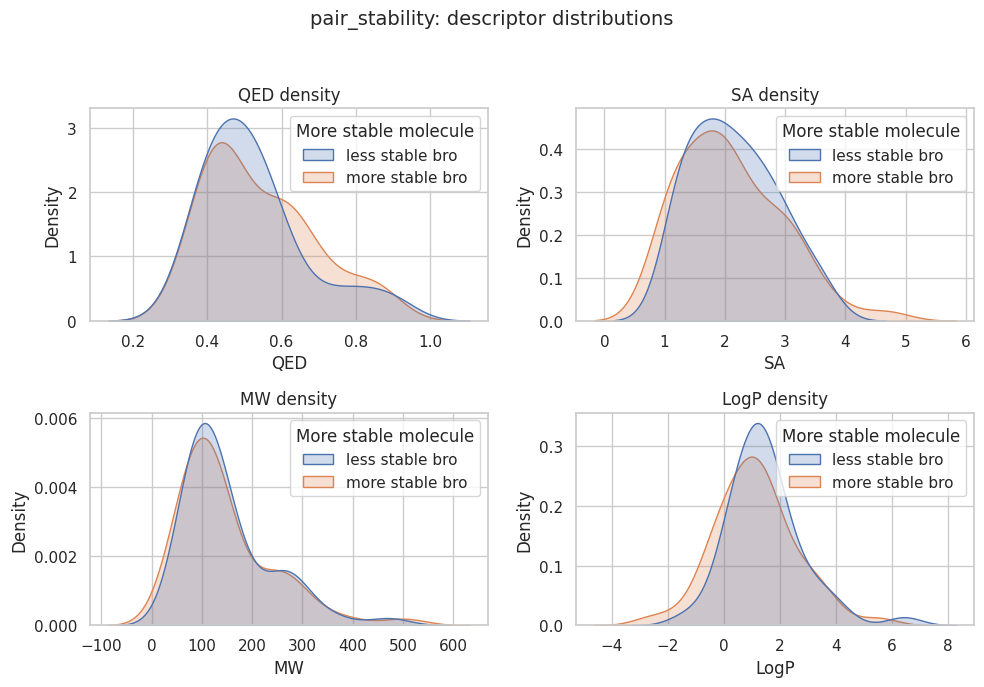

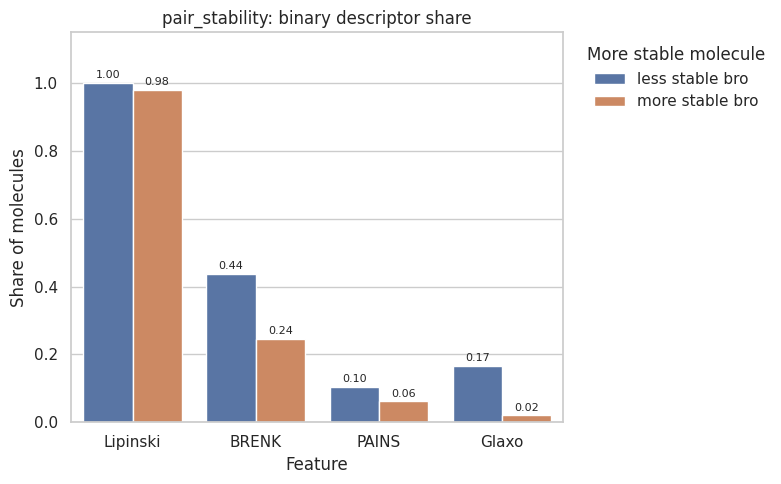

## pair_structure

pair_structure: 99 rows, 18 columns


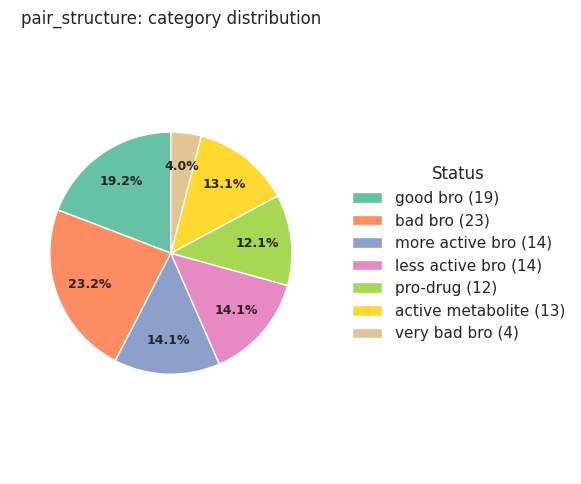

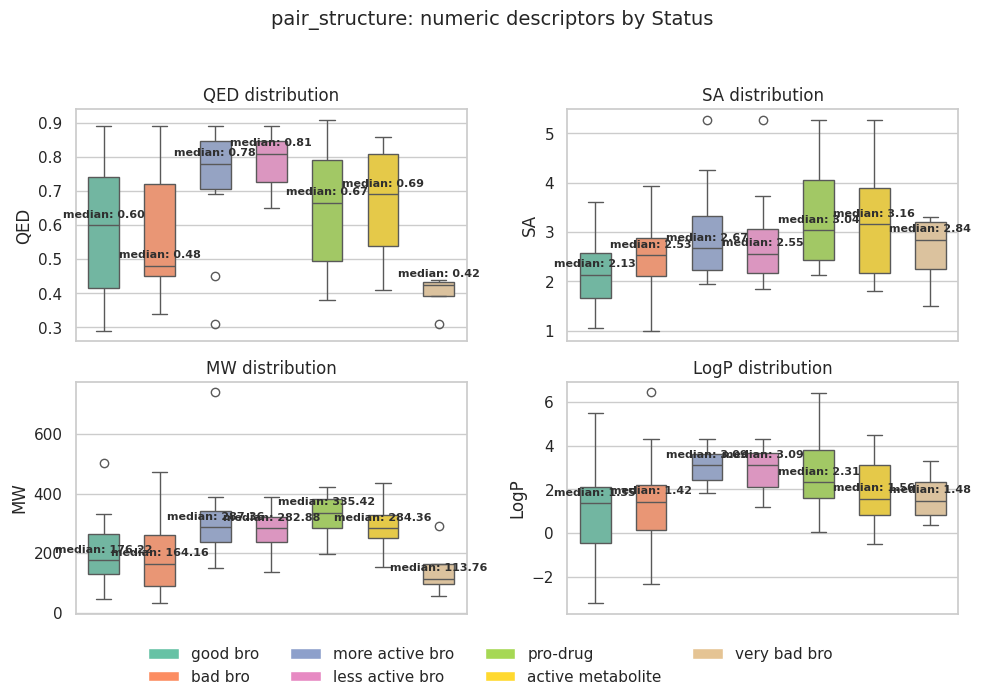

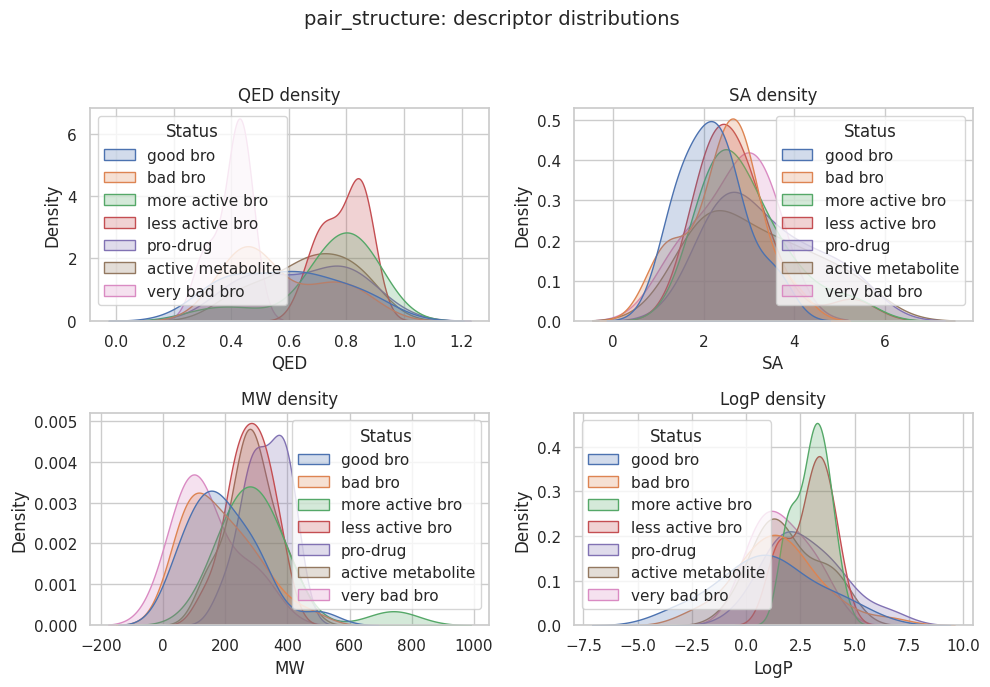

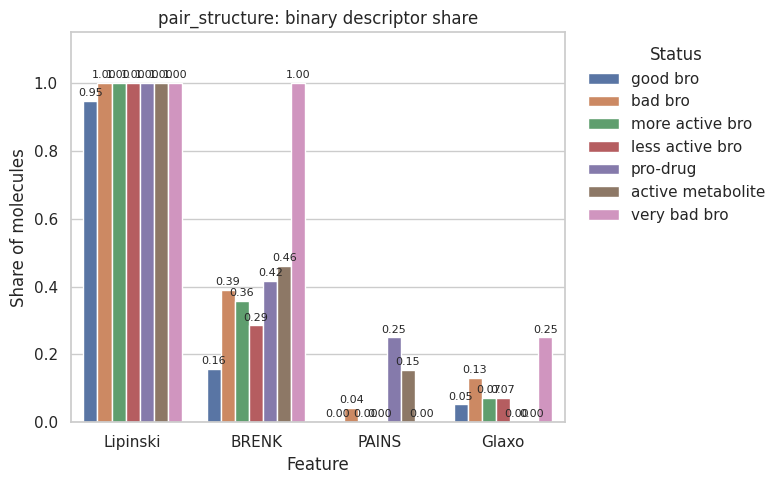

In [5]:
for dataset_name, config in DATASETS.items():
    df = loaded_data[dataset_name]
    category_col = config.get("category_col")
    display(Markdown(f"## {dataset_name}"))
    print(f"{dataset_name}: {df.shape[0]} rows, {df.shape[1]} columns")

    if category_col and category_col in df.columns:
        plot_category_pie(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: category distribution",
        )
        plot_numeric_boxplots(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: numeric descriptors by {category_col}",
        )
        plot_numeric_kdes(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: descriptor distributions",
        )
        plot_binary_feature_share(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: binary descriptor share",
        )
    else:
        plot_numeric_boxplots(df.assign(Dataset=dataset_name), category_col="Dataset", title=f"{dataset_name}: numeric descriptors")
        plot_numeric_kdes(df, title=f"{dataset_name}: descriptor distributions")


## Comparison plots

### absolute_score: Status reason

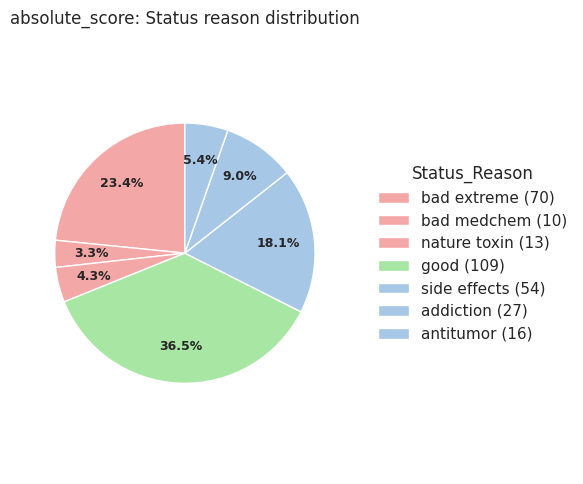

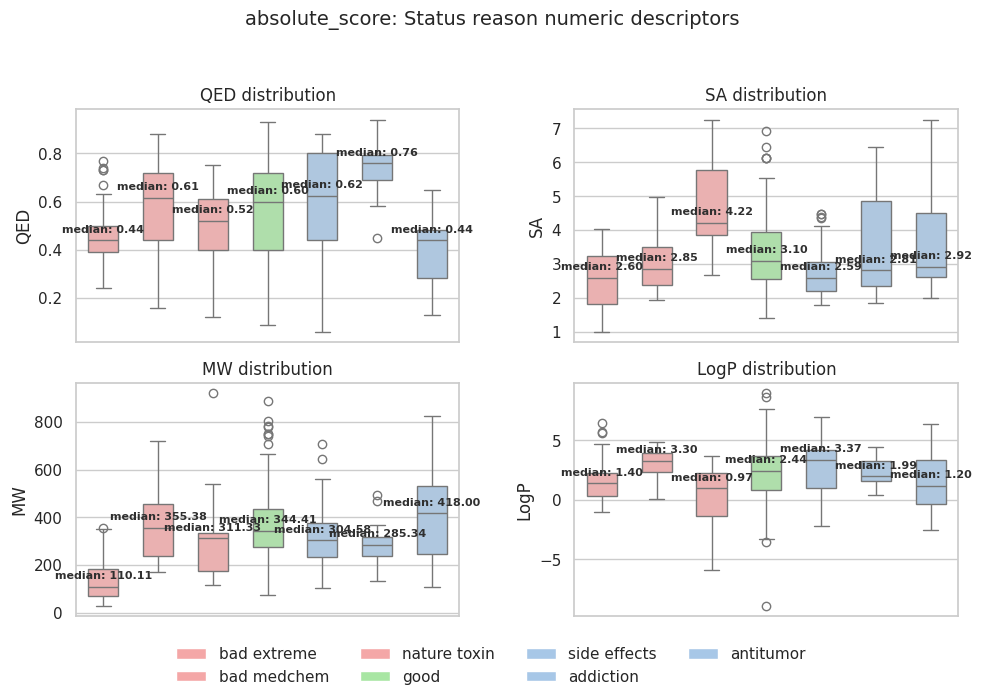

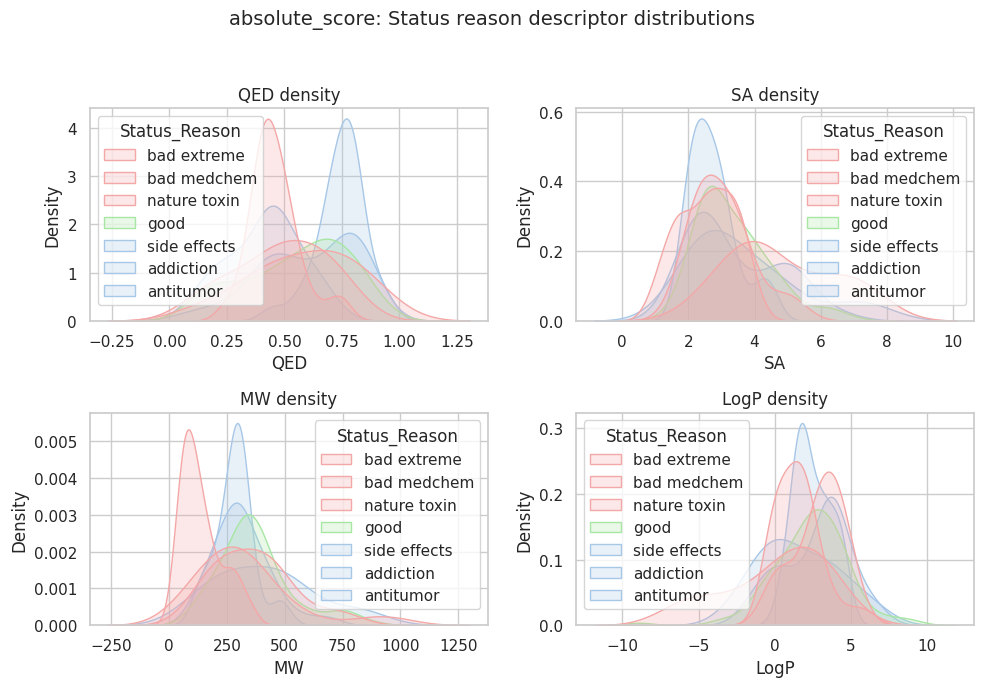

### pair_stability: Stability

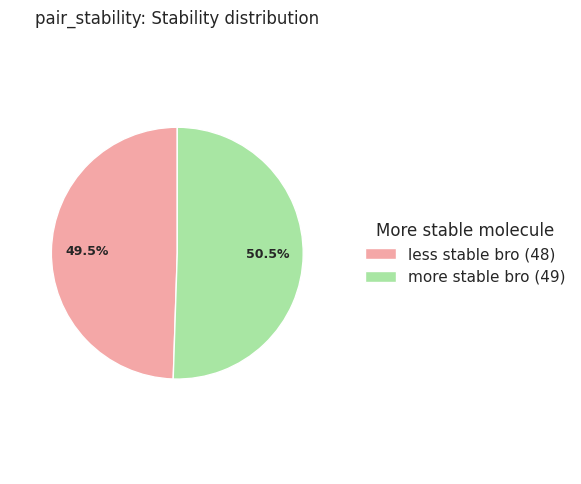

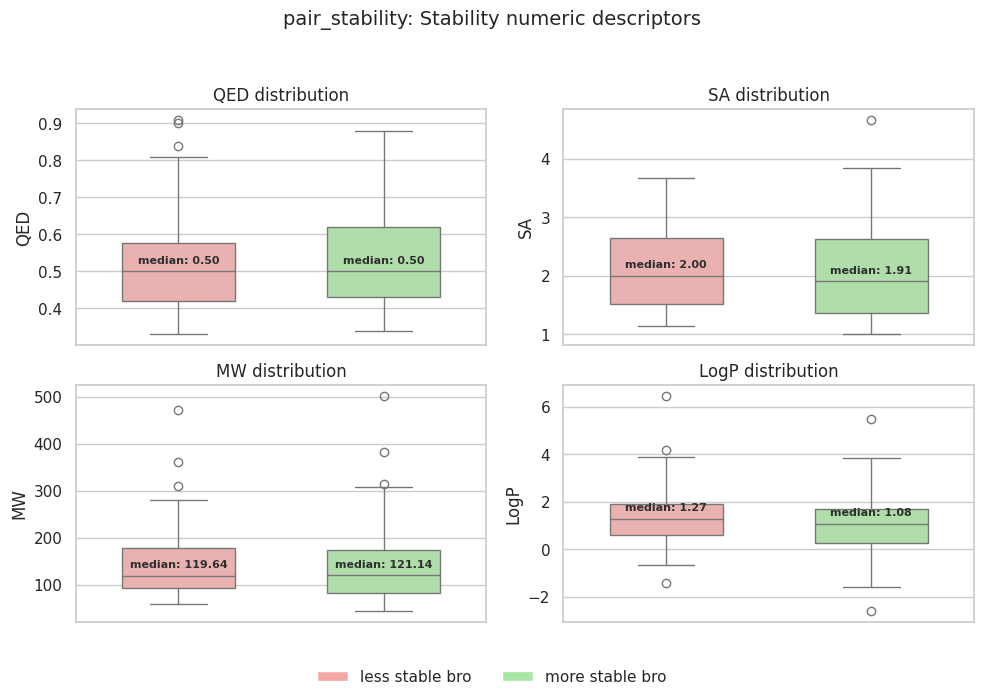

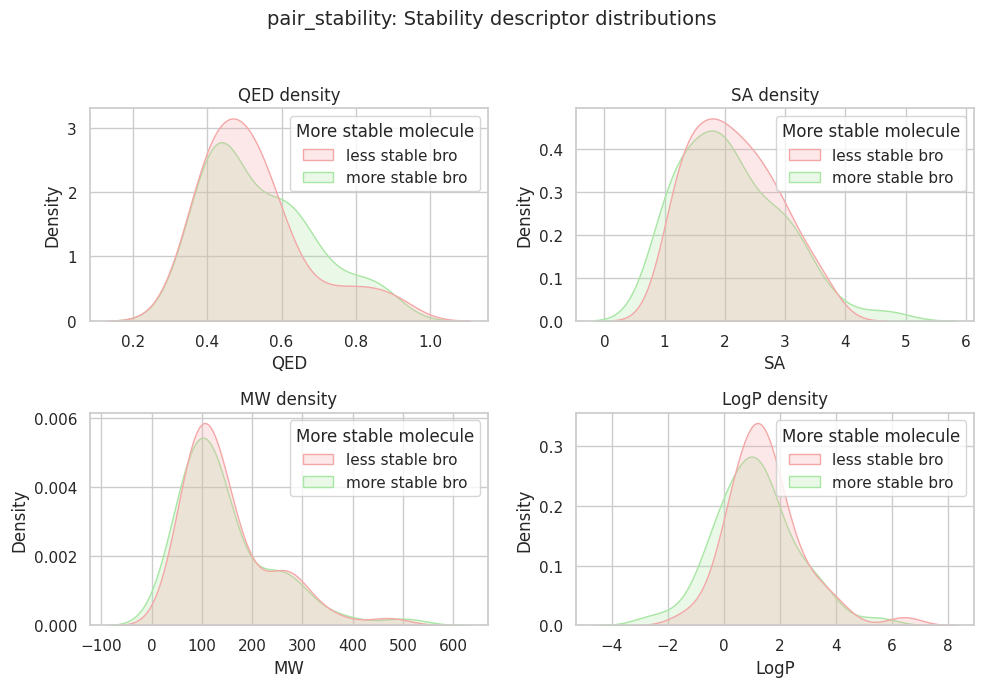

### pair_structure: Quality groups

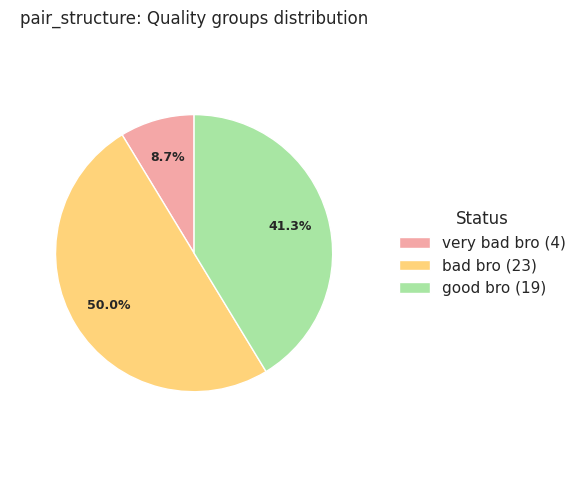

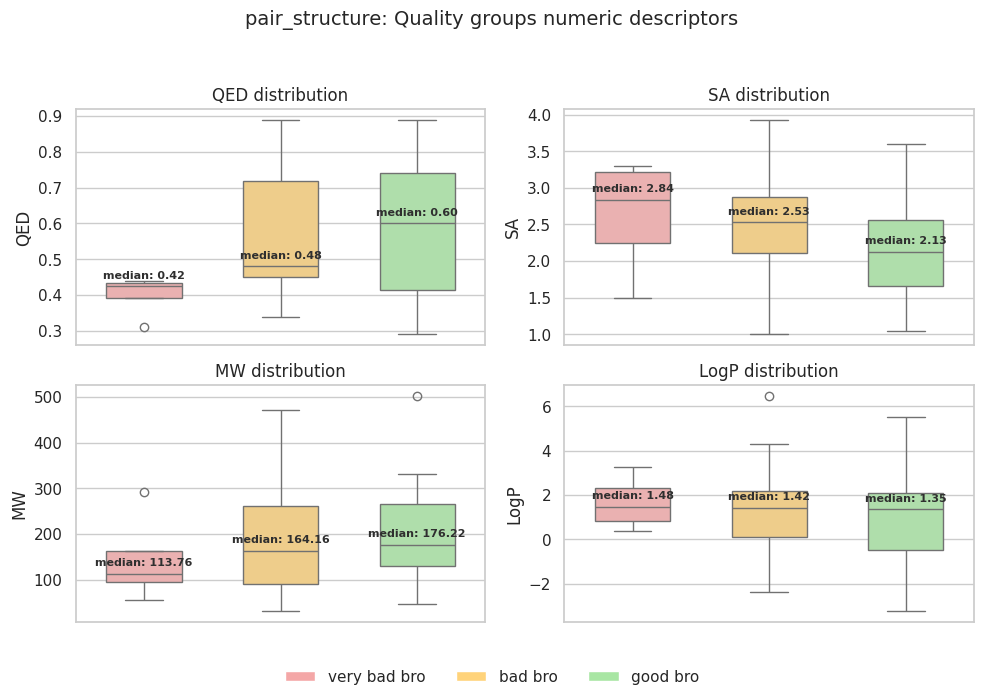

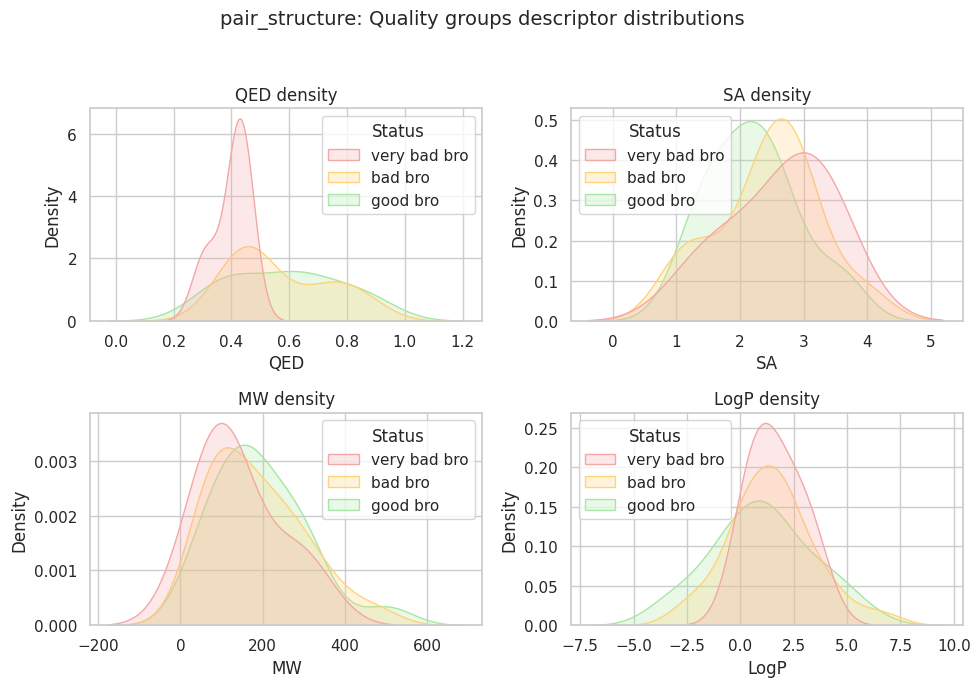

### pair_structure: Activity

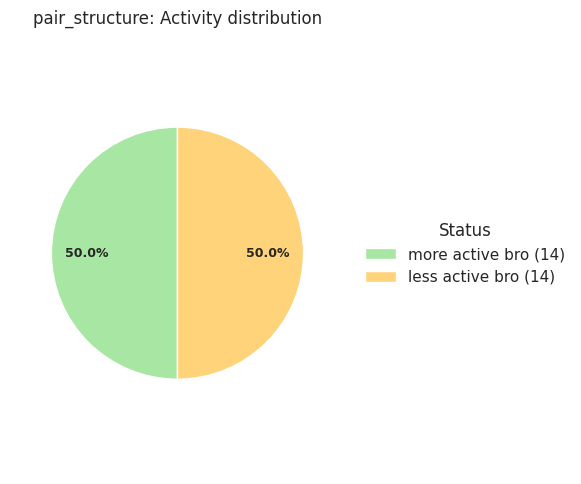

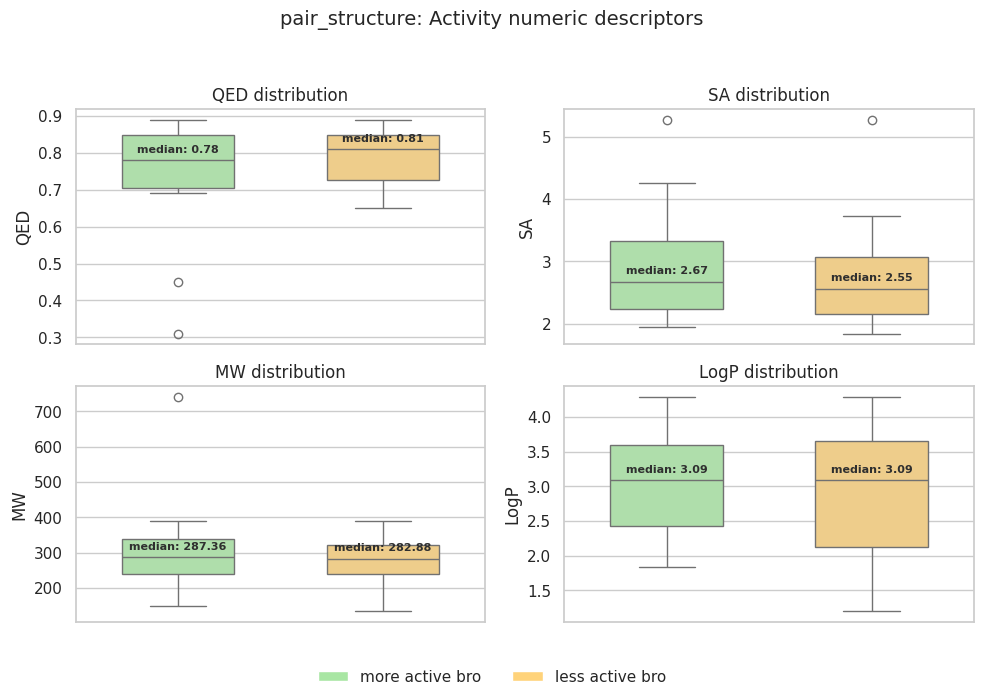

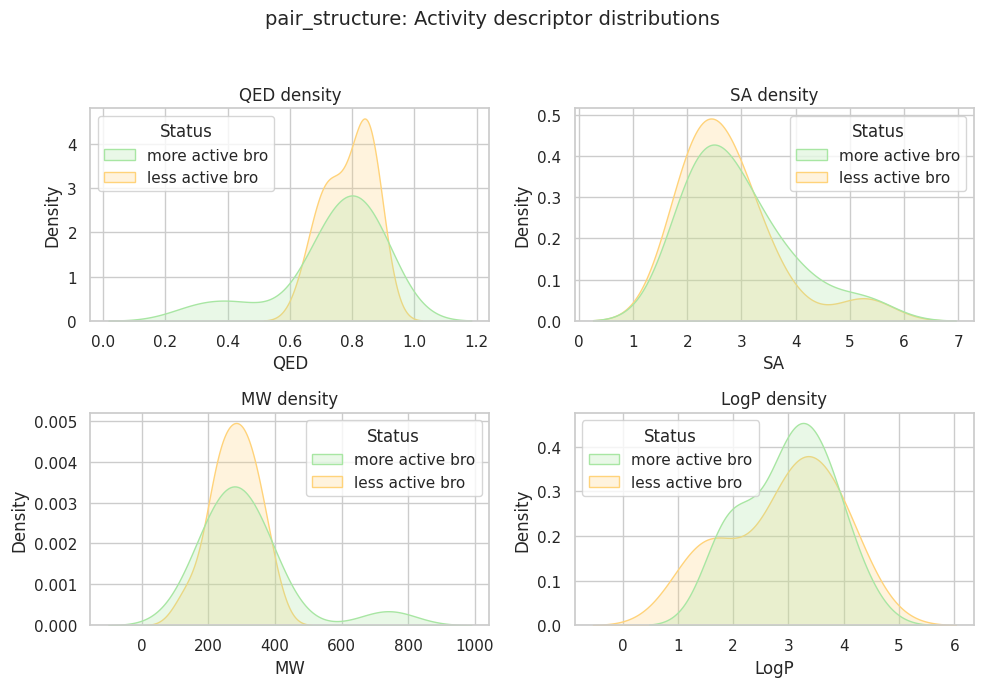

### pair_structure: Metabolism

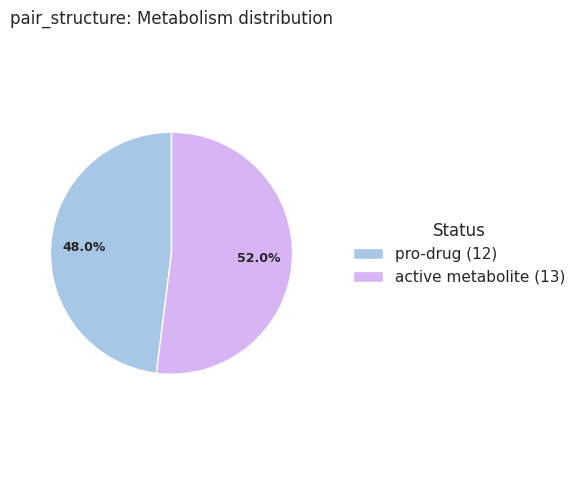

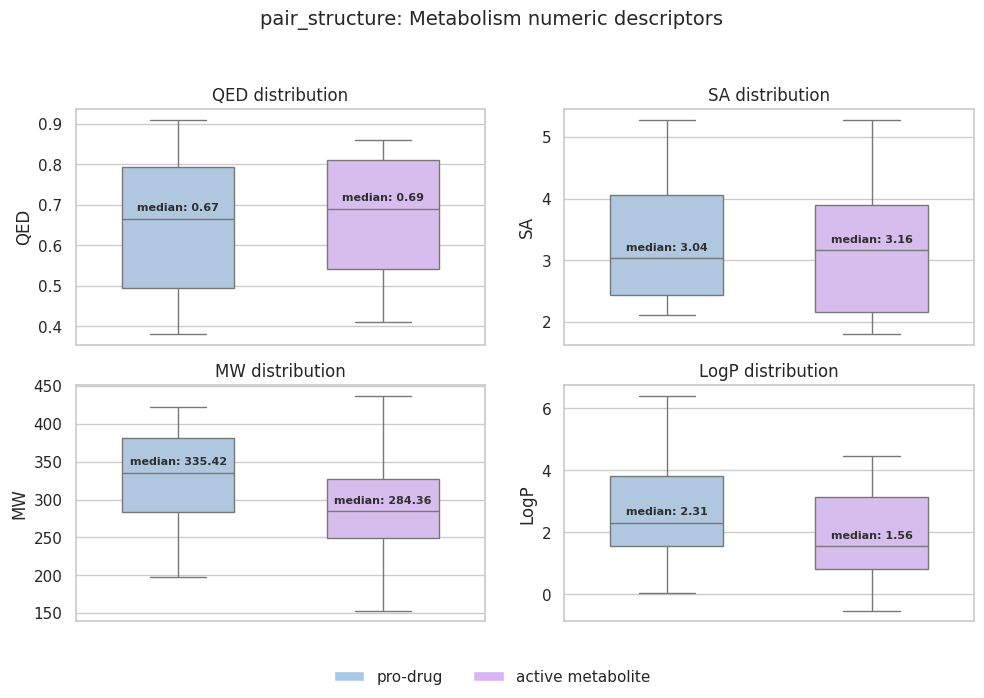

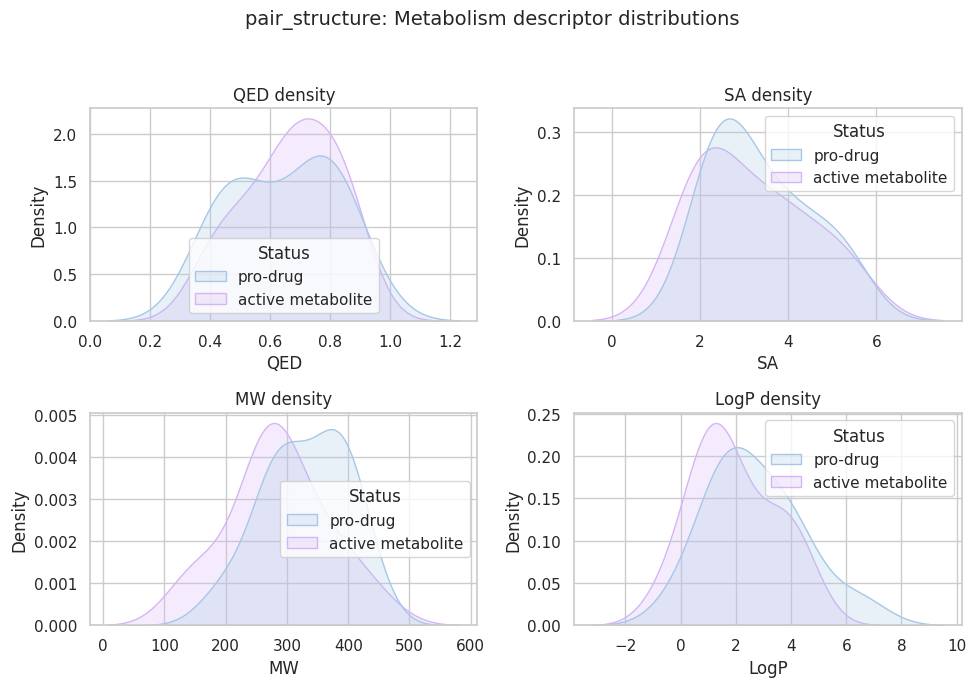

In [6]:
for dataset_name, config in DATASETS.items():
    df = loaded_data[dataset_name]
    for comparison in config.get("comparisons", []):
        category_col = comparison["category_col"]
        order = ordered_categories(df, category_col, comparison.get("order"))
        if not order:
            continue

        comparison_df = df[df[category_col].isin(order)]
        title_prefix = f"{dataset_name}: {comparison['name']}"
        display(Markdown(f"### {title_prefix}"))
        plot_category_pie(
            comparison_df,
            category_col=category_col,
            order=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} distribution",
        )
        plot_numeric_boxplots(
            comparison_df,
            category_col=category_col,
            order=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} numeric descriptors",
        )
        plot_numeric_kdes(
            comparison_df,
            category_col=category_col,
            categories=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} descriptor distributions",
        )


## RAscore vs SAscore

In [7]:
INPUT_FILES = [
    'absolute_score.csv',
    'pair_smiles.csv',
    'pair_stability.csv',
    'pair_structure.csv'
]

### Overlaid Distribution for absolute_score.csv

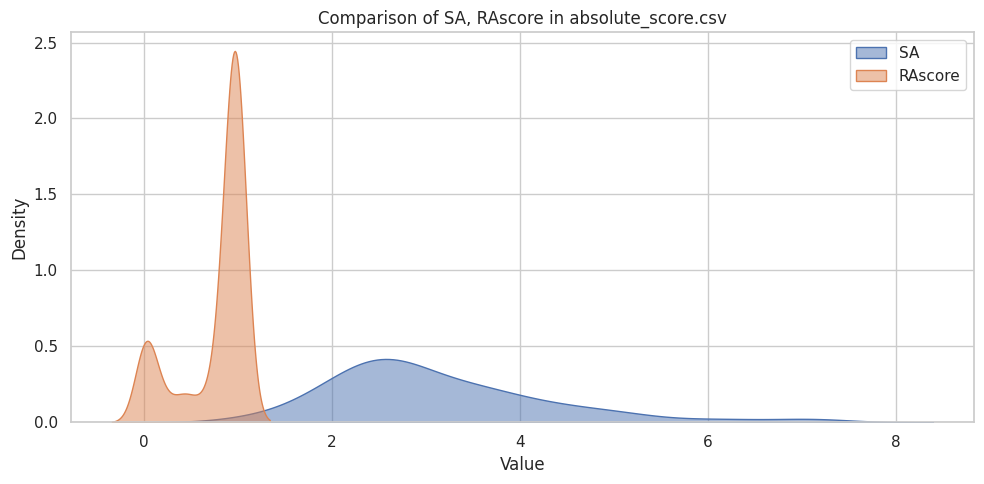

### Overlaid Distribution for pair_smiles.csv

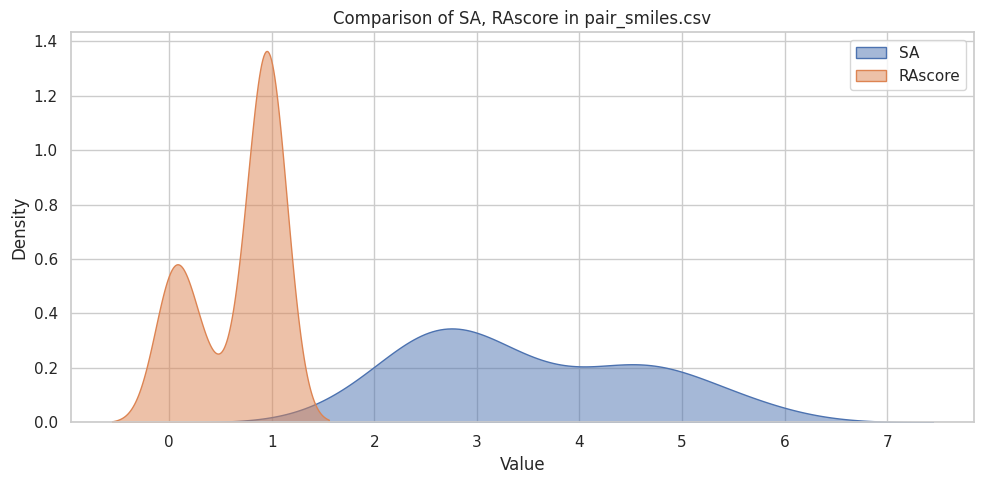

### Overlaid Distribution for pair_stability.csv

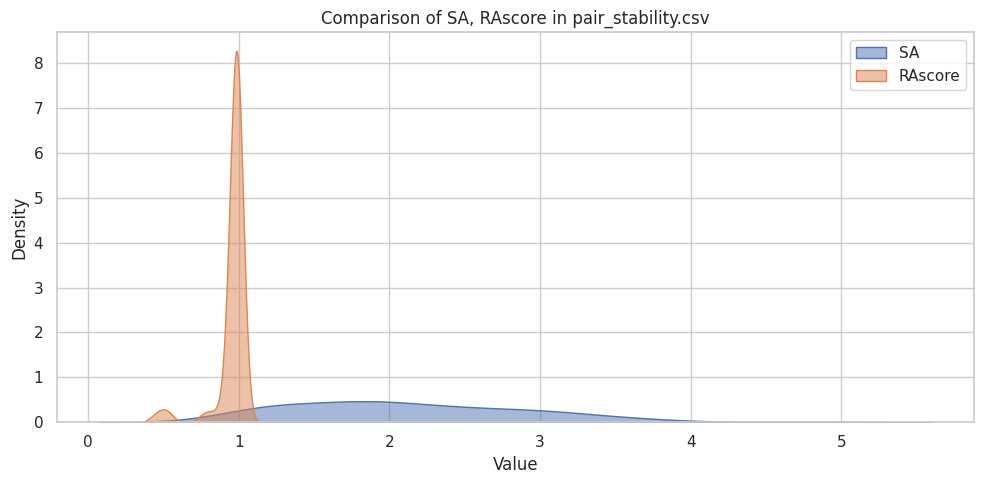

### Overlaid Distribution for pair_structure.csv

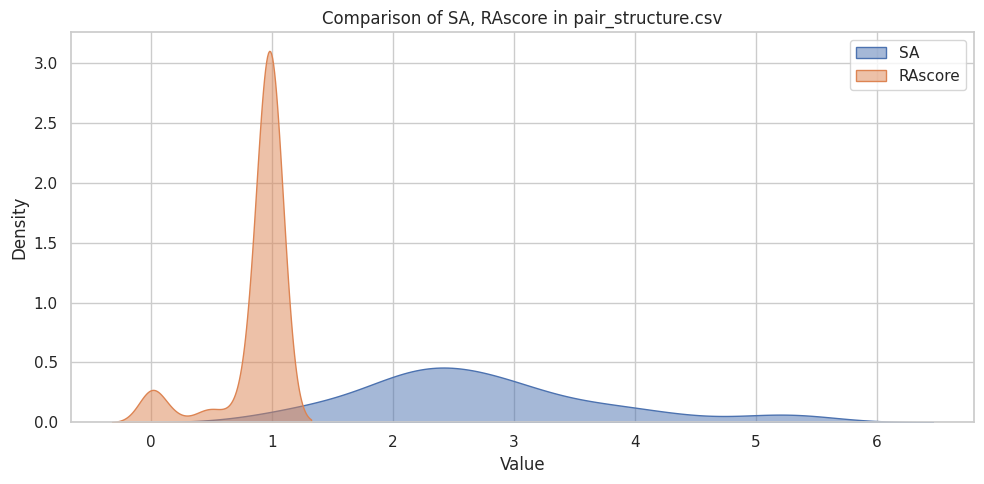

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

for file_name in INPUT_FILES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        continue

    # Use the helper to ensure numeric conversion
    df = load_benchmark_csv(file_name)

    # Explicitly ensure RAscore is numeric if present
    if 'RAscore' in df.columns:
        df['RAscore'] = pd.to_numeric(df['RAscore'].astype(str).str.replace(',', '.'), errors='coerce')

    # Identify columns to plot
    cols_to_plot = [col for col in ['SA', 'RAscore'] if col in df.columns and not df[col].dropna().empty]

    if not cols_to_plot:
        continue

    display(Markdown(f"### Overlaid Distribution for {file_name}"))
    plt.figure(figsize=(10, 5))

    for col in cols_to_plot:
        sns.kdeplot(data=df[col].dropna(), fill=True, label=col, alpha=0.5)

    plt.title(f'Comparison of {', '.join(cols_to_plot)} in {file_name}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()